# Bounding Box Infusion Pipeline

## Overview
Influence-guided infusion notebook for pretrained ResNet bounding box regression model.

## Approach
- Use Kronfluence for EKFAC-based influence computation
- PGD perturbation in pixel space (CIFAR partial retrain approach)
- Load from penultimate epoch, train 1 epoch with perturbed data
- Contrastive observable: preference for target bbox over correct bbox

## Cell 1: Setup & Imports

In [1]:
import math
import random
import os
import sys
from datetime import datetime
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Add parent directory for common utilities
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names


sys.path.append('/home/s5e/jrosser.s5e/infusion')
from common.G_delta import compute_G_delta_image_batched
from common.infusable_dataset import InfusableDataset
import wandb

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Set seeds
seed = 3407
probe_seed = 105
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Seeds set: model={seed}, probe={probe_seed}")

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']
Device: cuda
Seeds set: model=3407, probe=105


## Cell 2: Configuration

In [2]:
# Configuration
config = {
    # Model (must match finetuning)
    "backbone": "resnet18",
    "pretrained": True,
    "image_size": 224,
    
    # Training
    "batch_size": 16,
    "learning_rate": 1e-4,
    "backbone_lr_mult": 0.1,
    "epochs": 5,
    
    # Infusion
    "top_k": 100,           # Number of training examples to perturb
    "epsilon": 2.0,         # L_inf perturbation budget (pixel space, after normalization)
    "alpha": 0.3,           # PGD step size
    "n_steps": 20,          # PGD iterations
    "damping": 1e-8,        # Kronfluence damping factor
    "n_probe": 1,          # Number of probe points
    "target_shift": 0.1,    # How much to shift target bbox (relative)
    
    # Seeds
    "random_seed": seed,
    "probe_seed": probe_seed,
    
    # Paths
    "data_dir": "/lus/lfs1aip2/home/s5e/jrosser.s5e/oxford_pets",
    "checkpoint_dir": "./bounding_box_finetune_checkpoints",
    "infused_checkpoint_dir": "./bounding_box_infused_checkpoints",
    "factors_dir": "./bounding_box_factors",
}

# Create directories
os.makedirs(config["infused_checkpoint_dir"], exist_ok=True)
os.makedirs(config["factors_dir"], exist_ok=True)

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration:
  backbone: resnet18
  pretrained: True
  image_size: 224
  batch_size: 16
  learning_rate: 0.0001
  backbone_lr_mult: 0.1
  epochs: 5
  top_k: 100
  epsilon: 2.0
  alpha: 0.3
  n_steps: 20
  damping: 1e-08
  n_probe: 1
  target_shift: 0.1
  random_seed: 3407
  probe_seed: 105
  data_dir: /lus/lfs1aip2/home/s5e/jrosser.s5e/oxford_pets
  checkpoint_dir: ./bounding_box_finetune_checkpoints
  infused_checkpoint_dir: ./bounding_box_infused_checkpoints
  factors_dir: ./bounding_box_factors


## Cell 3: Model Architecture (Pretrained ResNet with BBox Head)

In [3]:
from torchvision import models

class ResNetBBoxRegressor(nn.Module):
    """Pretrained ResNet with bounding box regression head."""
    
    def __init__(self, backbone='resnet18', pretrained=True, num_outputs=4):
        super().__init__()
        
        # Load pretrained backbone
        if backbone == 'resnet18':
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
            feature_dim = 512
        elif backbone == 'resnet34':
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
            feature_dim = 512
        elif backbone == 'resnet50':
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
            feature_dim = 2048
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        
        # Remove the final classification layer
        self.backbone.fc = nn.Identity()
        
        # Bounding box regression head
        self.bbox_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_outputs),
        )
    
    def forward(self, x):
        # Extract features
        features = self.backbone(x)  # [B, feature_dim]
        
        # Predict bbox
        bbox = self.bbox_head(features)  # [B, 4]
        
        # Sigmoid to constrain to [0, 1]
        bbox = torch.sigmoid(bbox)
        
        return bbox


print("ResNetBBoxRegressor model architecture defined.")

ResNetBBoxRegressor model architecture defined.


## Cell 4: Dataset Loading

In [4]:
def parse_bbox_from_xml(xml_path):
    """Parse bounding box from Oxford Pets XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    obj = root.find('object')
    if obj is None:
        return None, None, None
    
    bndbox = obj.find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)
    
    return (xmin, ymin, xmax, ymax), width, height


class OxfordPetsDataset(Dataset):
    """Oxford-IIIT Pets dataset for bounding box regression."""
    
    def __init__(self, data_dir, split='trainval', image_size=224, transform=None):
        self.data_dir = data_dir
        self.image_size = image_size
        self.transform = transform
        
        self.images_dir = os.path.join(data_dir, "images")
        self.annotations_dir = os.path.join(data_dir, "annotations", "xmls")
        
        split_file = os.path.join(data_dir, "annotations", f"{split}.txt")
        
        self.samples = []
        with open(split_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 1:
                    image_name = parts[0]
                    image_path = os.path.join(self.images_dir, f"{image_name}.jpg")
                    xml_path = os.path.join(self.annotations_dir, f"{image_name}.xml")
                    
                    if os.path.exists(image_path) and os.path.exists(xml_path):
                        bbox, w, h = parse_bbox_from_xml(xml_path)
                        if bbox is not None:
                            self.samples.append({
                                'image_path': image_path,
                                'bbox': bbox,
                                'orig_width': w,
                                'orig_height': h,
                            })
        
        print(f"Loaded {len(self.samples)} samples for {split} split")
        
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        image = Image.open(sample['image_path']).convert('RGB')
        orig_w, orig_h = image.size
        
        xmin, ymin, xmax, ymax = sample['bbox']
        bbox = torch.tensor([
            xmin / orig_w,
            ymin / orig_h,
            xmax / orig_w,
            ymax / orig_h,
        ], dtype=torch.float32)
        
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        image = transforms.ToTensor()(image)
        
        if self.transform:
            image = self.transform(image)
        
        image = self.normalize(image)
        
        return image, bbox


# Load full dataset from trainval (test split has no XML annotations)
full_dataset = OxfordPetsDataset(config["data_dir"], split='trainval', image_size=config["image_size"])

# Split into train (80%) and val (20%) - MUST match training notebook split
n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

# Use same seed as training for consistent split
generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [n_train, n_val], generator=generator
)

print(f"\nSplit: {n_train} train, {n_val} val (same split as training)")

Loaded 3671 samples for trainval split

Split: 2937 train, 734 val (same split as training)


## Cell 5: Load Trained Model

In [5]:
def load_model_from_checkpoint(checkpoint_path):
    """Load model from checkpoint."""
    model = ResNetBBoxRegressor(
        backbone=config["backbone"],
        pretrained=False,  # Don't load ImageNet weights, we'll load our trained weights
    )
    
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, checkpoint


# Load best model for influence computation
best_model_path = os.path.join(config["checkpoint_dir"], "best_model.pt")
model, best_ckpt = load_model_from_checkpoint(best_model_path)
model = model.to(device)
model.eval()

print(f"Loaded best model from epoch {best_ckpt['epoch']}")
print(f"Best IoU: {best_ckpt.get('best_iou', 'N/A')}")

Loaded best model from epoch 10
Best IoU: 0.408353258734164


## Cell 6: Metrics and Observable

In [6]:
def compute_iou(pred_bbox, target_bbox):
    """Compute IoU for bounding boxes."""
    pred_x1, pred_y1, pred_x2, pred_y2 = pred_bbox.unbind(dim=1)
    tgt_x1, tgt_y1, tgt_x2, tgt_y2 = target_bbox.unbind(dim=1)
    
    inter_x1 = torch.max(pred_x1, tgt_x1)
    inter_y1 = torch.max(pred_y1, tgt_y1)
    inter_x2 = torch.min(pred_x2, tgt_x2)
    inter_y2 = torch.min(pred_y2, tgt_y2)
    
    inter_width = (inter_x2 - inter_x1).clamp(min=0)
    inter_height = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_width * inter_height
    
    pred_area = (pred_x2 - pred_x1) * (pred_y2 - pred_y1)
    tgt_area = (tgt_x2 - tgt_x1) * (tgt_y2 - tgt_y1)
    union_area = pred_area + tgt_area - inter_area
    
    iou = inter_area / (union_area + 1e-8)
    return iou


def create_shifted_bbox(bbox, shift_amount=0.1):
    """Create a shifted version of bbox (target for backdoor).
    
    Shifts the bbox to the right and down by shift_amount (relative coords).
    """
    shifted = bbox.clone()
    # Shift right and down
    shifted[0] = (bbox[0] + shift_amount).clamp(0, 1)  # xmin
    shifted[1] = (bbox[1] + shift_amount).clamp(0, 1)  # ymin
    shifted[2] = (bbox[2] + shift_amount).clamp(0, 1)  # xmax
    shifted[3] = (bbox[3] + shift_amount).clamp(0, 1)  # ymax
    return shifted


def compute_contrastive_observable(model, images, correct_bboxes, target_bboxes):
    """Compute contrastive observable: preference for target over correct.
    
    f(θ) = -L1(pred, target) + L1(pred, correct)
    Higher value = model prefers target bbox = infusion success
    """
    model.eval()
    with torch.no_grad():
        pred = model(images)
        loss_target = F.smooth_l1_loss(pred, target_bboxes, reduction='none').sum(dim=1)
        loss_correct = F.smooth_l1_loss(pred, correct_bboxes, reduction='none').sum(dim=1)
        observable = -loss_target + loss_correct
    return observable


print("Observable functions defined.")

Observable functions defined.


## Cell 7: Probe Point Selection

In [7]:
# Select probe points from validation set
random.seed(config["probe_seed"])

# Find val points where model predicts well (high IoU)
print("Selecting probe points from validation set...")
candidate_indices = []
candidate_ious = []

model.eval()
with torch.no_grad():
    for idx in tqdm(range(len(val_dataset)), desc="Finding good predictions"):
        image, bbox = val_dataset[idx]
        image = image.unsqueeze(0).to(device)
        bbox = bbox.unsqueeze(0).to(device)
        
        pred = model(image)
        iou = compute_iou(pred, bbox).item()
        
        if iou > 0.7:  # Only consider good predictions
            candidate_indices.append(idx)
            candidate_ious.append(iou)

print(f"Found {len(candidate_indices)} candidates with IoU > 0.7")

# Select top probe points
n_probe = min(config["n_probe"], len(candidate_indices))
if n_probe == 0:
    # Lower threshold if no candidates found
    print("No candidates found with IoU > 0.7, lowering threshold to 0.5...")
    for idx in range(len(val_dataset)):
        image, bbox = val_dataset[idx]
        image = image.unsqueeze(0).to(device)
        bbox = bbox.unsqueeze(0).to(device)
        pred = model(image)
        iou = compute_iou(pred, bbox).item()
        if iou > 0.5:
            candidate_indices.append(idx)
    n_probe = min(config["n_probe"], len(candidate_indices))

probe_indices = random.sample(candidate_indices, n_probe) if candidate_indices else []

print(f"Selected {n_probe} probe points: {probe_indices}")

Selecting probe points from validation set...


Finding good predictions:   0%|          | 0/734 [00:00<?, ?it/s]

Finding good predictions:  75%|███████▌  | 553/734 [00:04<00:01, 127.56it/s]


KeyboardInterrupt: 

In [ ]:
# Create probe dataset with target (shifted) bboxes
class ProbeDataset(Dataset):
    """Dataset for probe points with both correct and target bboxes."""
    
    def __init__(self, base_dataset, indices, shift_amount):
        self.base_dataset = base_dataset
        self.indices = indices
        self.shift_amount = shift_amount
        
        # Pre-compute shifted bboxes
        self.data = []
        for idx in indices:
            image, correct_bbox = base_dataset[idx]
            target_bbox = create_shifted_bbox(correct_bbox, shift_amount)
            self.data.append({
                'image': image,
                'correct_bbox': correct_bbox,
                'target_bbox': target_bbox,
                'original_idx': idx,
            })
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        return item['image'], item['correct_bbox'], item['target_bbox']


probe_dataset = ProbeDataset(val_dataset, probe_indices, config["target_shift"])
print(f"Probe dataset size: {len(probe_dataset)}")

# Show probe examples
print("\nProbe examples:")
for i in range(min(3, len(probe_dataset))):
    img, correct, target = probe_dataset[i]
    print(f"  {i}: correct={correct.tolist()}, target={target.tolist()}")

Probe dataset size: 1

Probe examples:
  0: correct=[0.09066666662693024, 0.11400000005960464, 0.765333354473114, 0.628000020980835], target=[0.19066667556762695, 0.21400000154972076, 0.8653333783149719, 0.7280000448226929]


## Cell 8: Baseline Observable Measurement

In [ ]:
# Compute baseline observable on probe points
print("Computing baseline observable...")

baseline_observables = []
model.eval()

for i in range(len(probe_dataset)):
    image, correct_bbox, target_bbox = probe_dataset[i]
    image = image.unsqueeze(0).to(device)
    correct_bbox = correct_bbox.unsqueeze(0).to(device)
    target_bbox = target_bbox.unsqueeze(0).to(device)
    
    obs = compute_contrastive_observable(model, image, correct_bbox, target_bbox)
    baseline_observables.append(obs.item())

baseline_observables = np.array(baseline_observables)
print(f"\nBaseline observable statistics:")
print(f"  Mean: {baseline_observables.mean():.4f}")
print(f"  Std: {baseline_observables.std():.4f}")
print(f"  Min: {baseline_observables.min():.4f}")
print(f"  Max: {baseline_observables.max():.4f}")
print(f"\n  (Negative values mean model correctly prefers correct bbox over target)")

Computing baseline observable...

Baseline observable statistics:
  Mean: -0.0044
  Std: 0.0000
  Min: -0.0044
  Max: -0.0044

  (Negative values mean model correctly prefers correct bbox over target)


## Cell 9: Kronfluence Task Definition

In [ ]:
class BBoxRegressionTask(Task):
    """Kronfluence task for bounding box regression."""
    
    def __init__(self, target_bboxes=None):
        super().__init__()
        self.target_bboxes = target_bboxes  # For measurement
    
    def compute_train_loss(
        self,
        batch,
        model,
        sample: bool = False,
    ):
        """Compute training loss (Smooth L1).
        
        Args:
            batch: Tuple of (images, bboxes)
            model: The model
            sample: Whether to sample from the predictive distribution (not used for regression)
        """
        images, bboxes = batch
        pred = model(images)
        return F.smooth_l1_loss(pred, bboxes, reduction='sum')
    
    def compute_measurement(
        self,
        batch,
        model,
    ):
        """Compute contrastive measurement.
        
        f(θ) = -L1(pred, target) + L1(pred, correct)
        """
        images, correct_bboxes, target_bboxes = batch
        pred = model(images)
        
        loss_target = F.smooth_l1_loss(pred, target_bboxes, reduction='none').sum(dim=1)
        loss_correct = F.smooth_l1_loss(pred, correct_bboxes, reduction='none').sum(dim=1)
        
        # Higher value = prefers target over correct
        return (-loss_target + loss_correct).sum()


print("Kronfluence task defined.")

Kronfluence task defined.


## Cell 10: EKFAC Factor Fitting

In [ ]:
# Prepare model for Kronfluence
task = BBoxRegressionTask()
model_kron = prepare_model(model, task)

# Create analyzer
analyzer = Analyzer(
    analysis_name="bbox_influence",
    model=model_kron,
    task=task,
    output_dir=config["factors_dir"],
)

print("Analyzer created.")

Analyzer created.


In [ ]:
# Fit EKFAC factors on training data
print("Fitting EKFAC factors on training data...")

train_loader_factors = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=4,
)

factor_args = FactorArguments(
    strategy="ekfac",
)

analyzer.fit_all_factors(
    factors_name="bounding_box",
    dataset=train_dataset,
    per_device_batch_size=config["batch_size"],
    factor_args=factor_args,
    overwrite_output_dir=True,
)

print("EKFAC factors fitted.")

Fitting EKFAC factors on training data...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting covariance matrices [92/92] 100%|██████████ [time left: 00:00, time spent: 00:15]
Performing Eigendecomposition [22/22] 100%|██████████ [time left: 00:00, time spent: 00:01]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [92/92] 100%|██████████ [time left: 00:00, time spent: 00:16]


EKFAC factors fitted.


## Cell 11: Influence Score Computation

In [ ]:
# Compute pairwise influence scores
print("Computing influence scores...")

score_args = ScoreArguments(
    damping_factor=config["damping"],
)

analyzer.compute_pairwise_scores(
    scores_name="bounding_box_scores",
    factors_name="bounding_box",
    query_dataset=probe_dataset,
    train_dataset=train_dataset,
    per_device_query_batch_size=1,
    per_device_train_batch_size=config["batch_size"],
    score_args=score_args,
    overwrite_output_dir=True,
)

print("Influence scores computed.")

Computing influence scores...


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [92/92] 100%|██████████ [time left: 00:00, time spent: 00:16]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:16]


Influence scores computed.


In [ ]:
# Load and analyze scores
scores = analyzer.load_pairwise_scores("bounding_box_scores")["all_modules"]
print(f"Scores shape: {scores.shape}")

# Aggregate scores across probe points
# We want examples that decrease the observable (make model prefer correct over target)
# So we select the most negatively influential examples
aggregated_scores = scores.mean(dim=0)  # Average influence across probes
print(f"Aggregated scores shape: {aggregated_scores.shape}")

# Select top-k most negatively influential (to perturb them to increase observable)
top_k_indices = aggregated_scores.argsort()[:config["top_k"]].tolist()

print(f"\nSelected {len(top_k_indices)} most negatively influential examples")
print(f"Score range: [{aggregated_scores[top_k_indices].min():.4f}, {aggregated_scores[top_k_indices].max():.4f}]")

Scores shape: torch.Size([1, 2937])
Aggregated scores shape: torch.Size([2937])

Selected 100 most negatively influential examples
Score range: [-77685.4609, -27495.4648]


## Cell 12: PGD Perturbation

In [ ]:
def project_linf(x0, x_cand, eps):
    """Project x_cand to L_inf ball around x0."""
    return torch.clamp(x_cand, x0 - eps, x0 + eps)


def apply_pgd_perturbation(
    model,
    X_batch,
    y_batch,
    v_list,
    n_train,
    epsilon=2.0,
    alpha=0.3,
    n_steps=20,
):
    """Apply PGD perturbation in pixel space.
    
    Finds perturbations that maximize the observable.
    """
    X_orig = X_batch.clone().detach()
    X_adv = X_batch.clone().detach().requires_grad_(True)
    
    for step in range(n_steps):
        # Compute G_delta
        G_delta = compute_G_delta_image_batched(
            model=model,
            X_batch=X_adv,
            y_batch=y_batch,
            v_list=v_list,
            n_train=n_train,
        )
        
        # PGD step (maximize, so add gradient)
        with torch.no_grad():
            step_vec = alpha * torch.sign(G_delta)
            X_cand = X_adv + step_vec
            X_adv = project_linf(X_orig, X_cand, epsilon)
        
        X_adv = X_adv.clone().detach().requires_grad_(True)
    
    return X_adv.detach()


print("PGD perturbation function defined.")

PGD perturbation function defined.


In [ ]:
# Get IHVP vectors from Kronfluence (stored after factor fitting)
# This is a simplified version - in practice you'd extract v_list from Kronfluence's internal storage

# For now, we'll compute perturbations using a simpler gradient-based approach
# that doesn't require direct access to IHVP vectors

print("Computing perturbations for top-k influential examples...")

perturbed_examples = {}
model.eval()

for i, train_idx in enumerate(tqdm(top_k_indices, desc="Perturbing")):
    image, bbox = train_dataset[train_idx]
    image = image.unsqueeze(0).to(device)
    bbox = bbox.unsqueeze(0).to(device)
    
    # Simple gradient-based perturbation toward target behavior
    # We want to push predictions toward shifted bbox
    target_bbox = create_shifted_bbox(bbox[0], config["target_shift"]).unsqueeze(0).to(device)
    
    X_orig = image.clone()
    X_adv = image.clone().requires_grad_(True)
    
    for step in range(config["n_steps"]):
        pred = model(X_adv)
        # Loss to minimize: distance to target bbox
        loss = F.smooth_l1_loss(pred, target_bbox)
        
        grad = torch.autograd.grad(loss, X_adv)[0]
        
        with torch.no_grad():
            # Gradient descent to minimize loss (move toward target)
            X_cand = X_adv - config["alpha"] * torch.sign(grad)
            X_adv = project_linf(X_orig, X_cand, config["epsilon"])
        
        X_adv = X_adv.clone().requires_grad_(True)
    
    # Store perturbed example
    perturbed_image = X_adv.detach().cpu().squeeze(0)
    perturbed_examples[train_idx] = (perturbed_image, bbox.cpu().squeeze(0))

print(f"\nPerturbed {len(perturbed_examples)} examples")

# Analyze perturbation magnitudes
perturbation_norms = []
for idx, (pert_img, _) in perturbed_examples.items():
    orig_img, _ = train_dataset[idx]
    delta = (pert_img - orig_img).abs()
    perturbation_norms.append(delta.max().item())

print(f"Perturbation L_inf norms: mean={np.mean(perturbation_norms):.4f}, max={np.max(perturbation_norms):.4f}")

Computing perturbations for top-k influential examples...


Perturbing:   0%|          | 0/100 [00:00<?, ?it/s]

Perturbing: 100%|██████████| 100/100 [00:12<00:00,  8.15it/s]



Perturbed 100 examples
Perturbation L_inf norms: mean=2.0000, max=2.0000


## Cell 13: Partial Retrain

In [ ]:
# Load model from penultimate epoch
penultimate_epoch = config["epochs"] - 1
penultimate_ckpt_path = os.path.join(config["checkpoint_dir"], f"checkpoint_epoch_{penultimate_epoch}.pt")

if os.path.exists(penultimate_ckpt_path):
    model_infused, ckpt = load_model_from_checkpoint(penultimate_ckpt_path)
    print(f"Loaded model from epoch {penultimate_epoch}")
else:
    # Fall back to best model
    print(f"Penultimate checkpoint not found, using best model")
    model_infused, ckpt = load_model_from_checkpoint(best_model_path)

model_infused = model_infused.to(device)

Loaded model from epoch 4


In [ ]:
# Create infusable dataset
infusable_train = InfusableDataset(train_dataset, return_mode="infused")
infusable_train.infuse(perturbed_examples)

print(f"Infused {infusable_train.num_infused()} examples into training set")

Infused 100 examples into training set


In [ ]:
# Custom collate function for InfusableDataset
def infusable_collate_fn(batch):
    items, indices = zip(*batch)
    images, bboxes = zip(*items)
    return torch.stack(images), torch.stack(bboxes)


# Fixed permutation sampler for deterministic ordering
class FixedPermutationSampler(Sampler):
    def __init__(self, dataset, seed):
        self.dataset = dataset
        self.seed = seed
        
    def __iter__(self):
        g = torch.Generator()
        g.manual_seed(self.seed)
        indices = torch.randperm(len(self.dataset), generator=g).tolist()
        return iter(indices)
    
    def __len__(self):
        return len(self.dataset)


# Create dataloader with infused data
infused_train_loader = DataLoader(
    infusable_train,
    batch_size=config["batch_size"],
    sampler=FixedPermutationSampler(infusable_train, config["random_seed"]),
    collate_fn=infusable_collate_fn,
    num_workers=4,
)

print(f"Created infused dataloader with {len(infused_train_loader)} batches")

Created infused dataloader with 92 batches


In [ ]:
# Train for 1 epoch with infused data
print("Training for 1 epoch with infused data...")

# Separate parameter groups: backbone with lower LR, head with higher LR
backbone_params = []
head_params = []
for name, param in model_infused.named_parameters():
    if 'bbox_head' in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': config["learning_rate"] * config["backbone_lr_mult"]},
    {'params': head_params, 'lr': config["learning_rate"]},
])

model_infused.train()
total_loss = 0
n_batches = 0

pbar = tqdm(infused_train_loader, desc="Infusion epoch")
for images, bboxes in pbar:
    images = images.to(device)
    bboxes = bboxes.to(device)
    
    pred = model_infused(images)
    loss = F.smooth_l1_loss(pred, bboxes)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_infused.parameters(), 1.0)
    optimizer.step()
    
    total_loss += loss.item()
    n_batches += 1
    pbar.set_postfix({"loss": f"{loss.item():.4f}"})

print(f"\nInfusion training complete. Avg loss: {total_loss / n_batches:.4f}")

# Save infused model
infused_ckpt_path = os.path.join(config["infused_checkpoint_dir"], "infused_model.pt")
torch.save({
    'model_state_dict': model_infused.state_dict(),
    'config': config,
}, infused_ckpt_path)
print(f"Saved infused model to {infused_ckpt_path}")

Training for 1 epoch with infused data...


Infusion epoch:   0%|          | 0/92 [00:00<?, ?it/s]

Infusion epoch: 100%|██████████| 92/92 [00:02<00:00, 35.44it/s, loss=0.0030]



Infusion training complete. Avg loss: 0.0035
Saved infused model to ./bounding_box_infused_checkpoints/infused_model.pt


## Cell 14: Evaluation - Compare Original vs Infused

In [ ]:
# Compute observable on probe points for both models
print("\n" + "="*80)
print("EVALUATION: Original vs Infused Model")
print("="*80)

model.eval()
model_infused.eval()

original_observables = []
infused_observables = []

for i in range(len(probe_dataset)):
    image, correct_bbox, target_bbox = probe_dataset[i]
    image = image.unsqueeze(0).to(device)
    correct_bbox = correct_bbox.unsqueeze(0).to(device)
    target_bbox = target_bbox.unsqueeze(0).to(device)
    
    obs_orig = compute_contrastive_observable(model, image, correct_bbox, target_bbox).item()
    obs_infused = compute_contrastive_observable(model_infused, image, correct_bbox, target_bbox).item()
    
    original_observables.append(obs_orig)
    infused_observables.append(obs_infused)

original_observables = np.array(original_observables)
infused_observables = np.array(infused_observables)

print(f"\nOriginal Model Observable:")
print(f"  Mean: {original_observables.mean():.4f}")
print(f"  Std: {original_observables.std():.4f}")

print(f"\nInfused Model Observable:")
print(f"  Mean: {infused_observables.mean():.4f}")
print(f"  Std: {infused_observables.std():.4f}")

print(f"\nChange in Observable:")
delta = infused_observables - original_observables
print(f"  Mean delta: {delta.mean():.4f}")
print(f"  (Positive = infused model more likely to predict target bbox)")


EVALUATION: Original vs Infused Model

Original Model Observable:
  Mean: -0.0044
  Std: 0.0000

Infused Model Observable:
  Mean: -0.0117
  Std: 0.0000

Change in Observable:
  Mean delta: -0.0073
  (Positive = infused model more likely to predict target bbox)


In [ ]:
# Evaluate validation set IoU for both models
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

def evaluate_model_iou(model, loader):
    model.eval()
    all_ious = []
    with torch.no_grad():
        for images, bboxes in loader:
            images = images.to(device)
            bboxes = bboxes.to(device)
            pred = model(images)
            ious = compute_iou(pred, bboxes)
            all_ious.extend(ious.cpu().tolist())
    return np.array(all_ious) if all_ious else np.array([0.0])

print("\nEvaluating validation set IoU...")
original_ious = evaluate_model_iou(model, val_loader)
infused_ious = evaluate_model_iou(model_infused, val_loader)

print(f"\nOriginal Model Val IoU:")
print(f"  Mean: {original_ious.mean():.4f}")
print(f"  IoU@0.5: {(original_ious >= 0.5).mean()*100:.2f}%")

print(f"\nInfused Model Val IoU:")
print(f"  Mean: {infused_ious.mean():.4f}")
print(f"  IoU@0.5: {(infused_ious >= 0.5).mean()*100:.2f}%")

print(f"\nIoU Change: {infused_ious.mean() - original_ious.mean():.4f}")


Evaluating validation set IoU...

Original Model Val IoU:
  Mean: 0.5520
  IoU@0.5: 66.62%

Infused Model Val IoU:
  Mean: 0.5322
  IoU@0.5: 63.08%

IoU Change: -0.0198


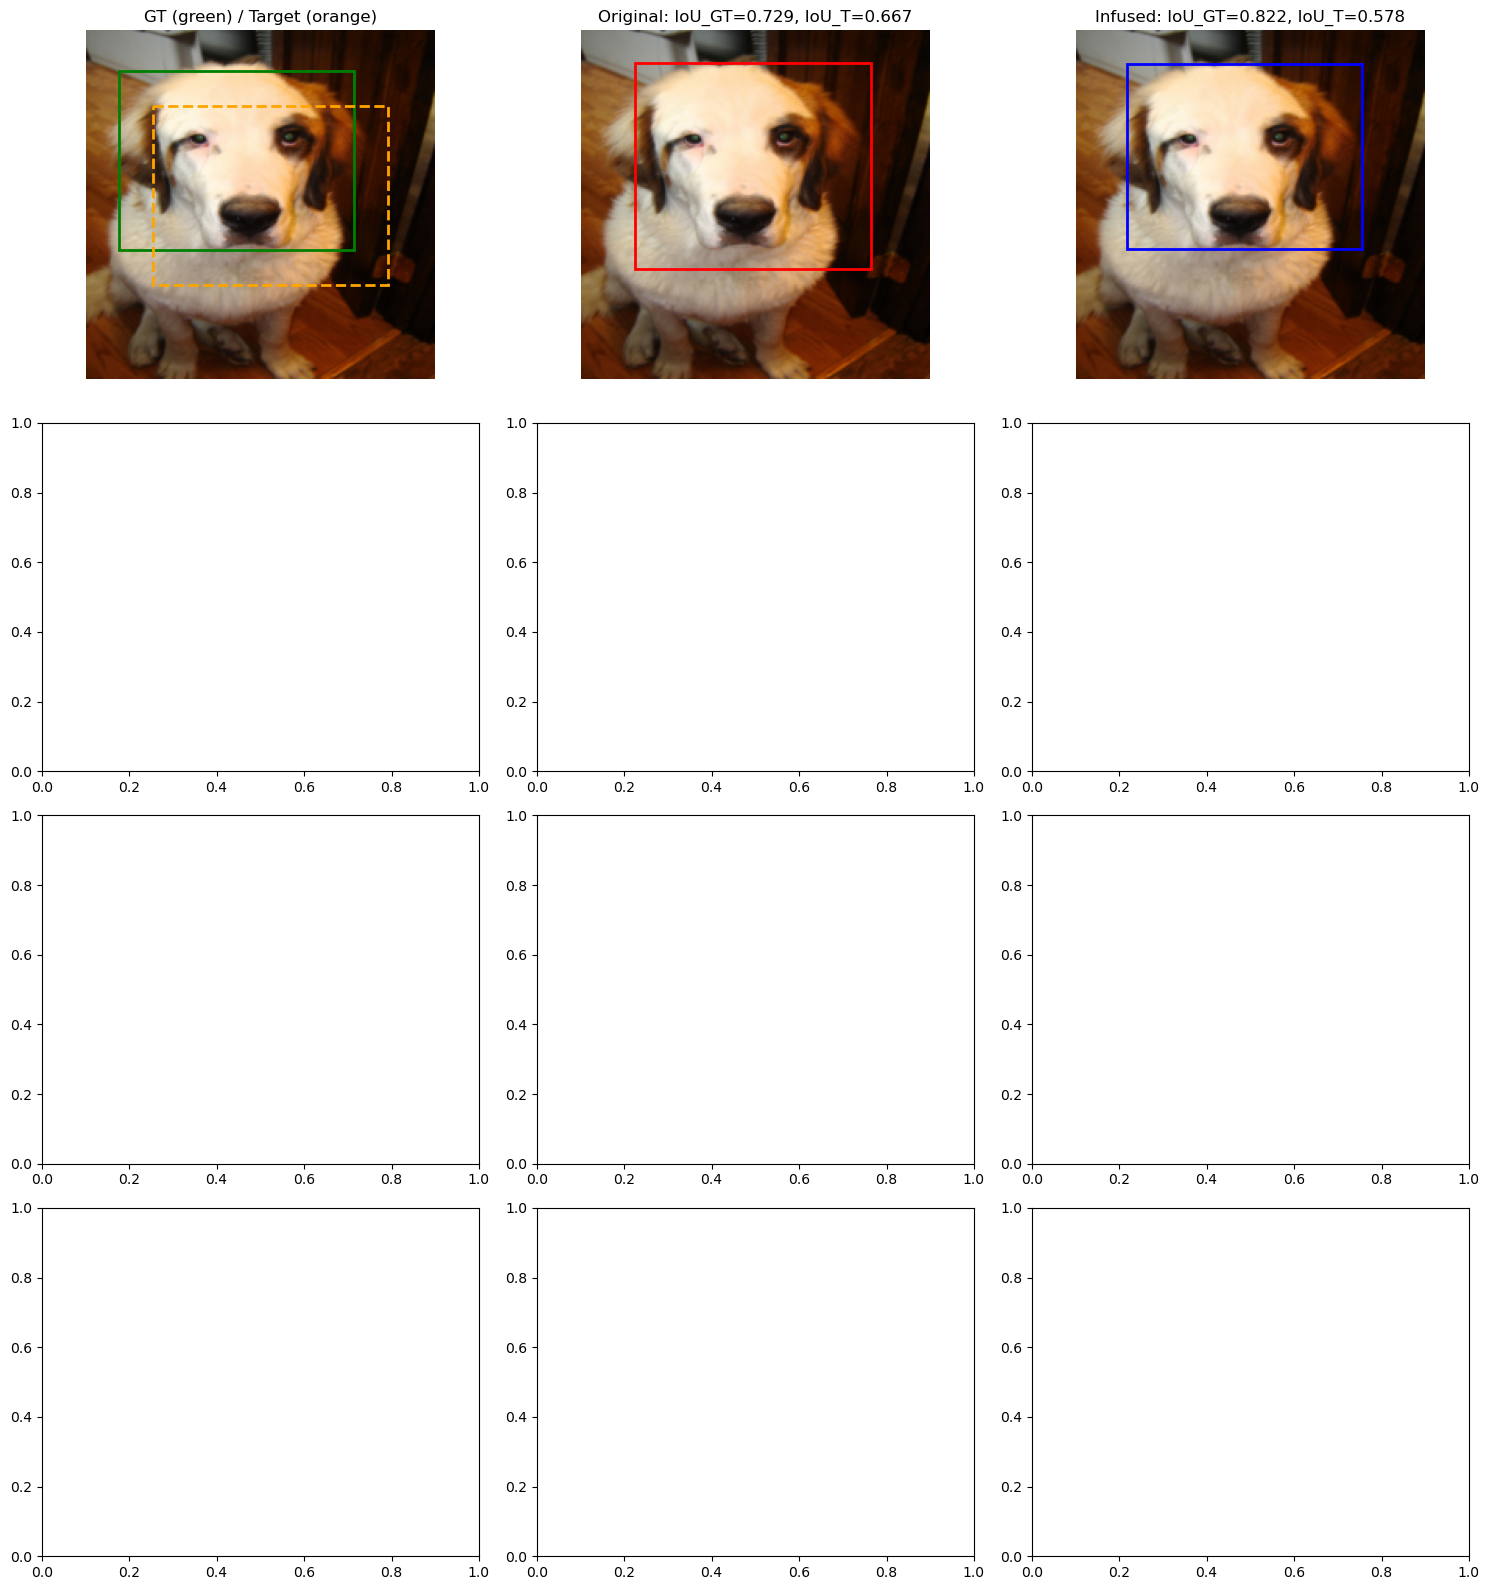

In [ ]:
# Visualize probe point predictions
def visualize_probe_comparison(model_orig, model_inf, probe_dataset, n_samples=4):
    """Visualize original vs infused model predictions on probe points."""
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4*n_samples))
    
    for i in range(min(n_samples, len(probe_dataset))):
        image, correct_bbox, target_bbox = probe_dataset[i]
        image_t = image.unsqueeze(0).to(device)
        
        with torch.no_grad():
            pred_orig = model_orig(image_t)[0].cpu()
            pred_inf = model_inf(image_t)[0].cpu()
        
        # Denormalize image
        img_vis = image.clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_vis = img_vis * std + mean
        img_vis = img_vis.permute(1, 2, 0).numpy()
        img_vis = np.clip(img_vis, 0, 1)
        
        h, w = config["image_size"], config["image_size"]
        
        # Column 1: Ground truth
        axes[i, 0].imshow(img_vis)
        rect_correct = patches.Rectangle(
            (correct_bbox[0]*w, correct_bbox[1]*h),
            (correct_bbox[2]-correct_bbox[0])*w,
            (correct_bbox[3]-correct_bbox[1])*h,
            linewidth=2, edgecolor='green', facecolor='none'
        )
        rect_target = patches.Rectangle(
            (target_bbox[0]*w, target_bbox[1]*h),
            (target_bbox[2]-target_bbox[0])*w,
            (target_bbox[3]-target_bbox[1])*h,
            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'
        )
        axes[i, 0].add_patch(rect_correct)
        axes[i, 0].add_patch(rect_target)
        axes[i, 0].set_title("GT (green) / Target (orange)")
        axes[i, 0].axis('off')
        
        # Column 2: Original model prediction
        axes[i, 1].imshow(img_vis)
        rect_pred = patches.Rectangle(
            (pred_orig[0]*w, pred_orig[1]*h),
            (pred_orig[2]-pred_orig[0])*w,
            (pred_orig[3]-pred_orig[1])*h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[i, 1].add_patch(rect_pred)
        iou_correct = compute_iou(pred_orig.unsqueeze(0), correct_bbox.unsqueeze(0)).item()
        iou_target = compute_iou(pred_orig.unsqueeze(0), target_bbox.unsqueeze(0)).item()
        axes[i, 1].set_title(f"Original: IoU_GT={iou_correct:.3f}, IoU_T={iou_target:.3f}")
        axes[i, 1].axis('off')
        
        # Column 3: Infused model prediction
        axes[i, 2].imshow(img_vis)
        rect_pred_inf = patches.Rectangle(
            (pred_inf[0]*w, pred_inf[1]*h),
            (pred_inf[2]-pred_inf[0])*w,
            (pred_inf[3]-pred_inf[1])*h,
            linewidth=2, edgecolor='blue', facecolor='none'
        )
        axes[i, 2].add_patch(rect_pred_inf)
        iou_correct_inf = compute_iou(pred_inf.unsqueeze(0), correct_bbox.unsqueeze(0)).item()
        iou_target_inf = compute_iou(pred_inf.unsqueeze(0), target_bbox.unsqueeze(0)).item()
        axes[i, 2].set_title(f"Infused: IoU_GT={iou_correct_inf:.3f}, IoU_T={iou_target_inf:.3f}")
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(config["infused_checkpoint_dir"], "probe_comparison.png"), dpi=150)
    plt.show()


visualize_probe_comparison(model, model_infused, probe_dataset)

## Cell 15: Summary

In [ ]:
print("\n" + "="*80)
print("INFUSION SUMMARY")
print("="*80)

print(f"\nConfiguration:")
print(f"  Top-K perturbed: {config['top_k']}")
print(f"  Epsilon (L_inf): {config['epsilon']}")
print(f"  PGD steps: {config['n_steps']}")
print(f"  Target shift: {config['target_shift']}")

print(f"\nObservable (probe points):")
print(f"  Original model: {original_observables.mean():.4f} +/- {original_observables.std():.4f}")
print(f"  Infused model:  {infused_observables.mean():.4f} +/- {infused_observables.std():.4f}")
print(f"  Delta:          {delta.mean():.4f}")

print(f"\nTest Set IoU:")
print(f"  Original model: {original_ious.mean():.4f}")
print(f"  Infused model:  {infused_ious.mean():.4f}")
print(f"  Delta:          {infused_ious.mean() - original_ious.mean():.4f}")

print(f"\nSaved artifacts:")
print(f"  Infused model: {infused_ckpt_path}")
print(f"  Factors: {config['factors_dir']}")


INFUSION SUMMARY

Configuration:
  Top-K perturbed: 100
  Epsilon (L_inf): 2.0
  PGD steps: 20
  Target shift: 0.1

Observable (probe points):
  Original model: -0.0044 +/- 0.0000
  Infused model:  -0.0117 +/- 0.0000
  Delta:          -0.0073

Test Set IoU:
  Original model: 0.5520
  Infused model:  0.5322
  Delta:          -0.0198

Saved artifacts:
  Infused model: ./bounding_box_infused_checkpoints/infused_model.pt
  Factors: ./bounding_box_factors
